# Lab: End-to-End MLP Pipeline — Face Recognition (Olivetti Faces)

**Objective:** Build a complete deep learning pipeline using a Multilayer Perceptron (MLP)
in PyTorch — from raw data to a trained, evaluated classifier.

**You will:**
1. Load and explore the dataset
2. Preprocess the data (handle missing values, encode/split, scale)
3. Design an MLP and choose activation functions
4. Choose a loss function and optimizer
5. Train the model manually (batch-by-batch)
6. Evaluate and visualize results

**Dataset:** Olivetti Faces — 400 grayscale images (64×64) of 40 people (10 images each).
Task: predict *which person* is in the image (40-class classification).

📌 Fill in every `None` and every `# TODO` comment. Do not change the fixed/given cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


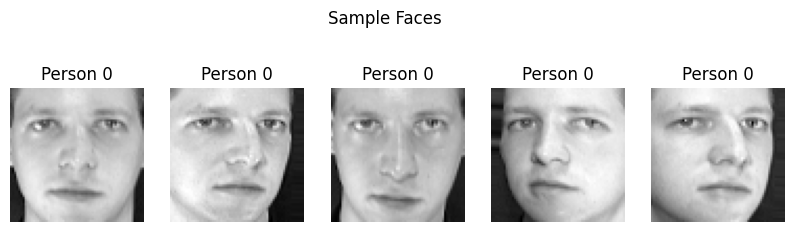

In [2]:
data = fetch_olivetti_faces()
X, y = data.data, data.target   # X: (400, 4096) flattened images, y: (400,) person labels 0-39

# TODO: print the shape of X and y
# TODO: print how many unique classes (people) there are
# TODO: print the min and max pixel value in X


# ---- Visualize a few samples (given — just run this) ----
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    ax.imshow(X[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"Person {y[i]}")
    ax.axis('off')
plt.suptitle("Sample Faces")
plt.show()

### Step 1: Preprocessing
Every ML pipeline needs these 3 things done properly:
1. Handle missing values (if any)
2. Split into train/test sets
3. Scale the features

Fill in the blanks below. Use the imports already given in Cell 2 — you don't need new ones.

In [3]:
# TODO 1: Check if there are any missing (NaN) values in X
# Hint: use np.isnan(...).any()
has_missing = None

print("Any missing values?", has_missing)

# TODO 2: Split X, y into train and test sets
# Requirements: test_size=0.2, stratify=y (so every person appears in both sets), random_state=42
# Hint: use train_test_split()
X_train, X_test, y_train, y_test = None, None, None, None

# TODO 3: Scale the features using StandardScaler
# IMPORTANT: fit the scaler ONLY on X_train, then use it to transform both X_train and X_test.
# Why only fit on train? (think about "data leakage" — write a 1-line comment explaining why)
scaler = None
X_train = None
X_test = None

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Any missing values? None


AttributeError: 'NoneType' object has no attribute 'shape'

### Step 2: Convert data to PyTorch tensors
PyTorch models need `torch.Tensor` inputs, not NumPy arrays.
- Use `dtype=torch.float32` for features (X)
- Use `dtype=torch.long` for labels (y) — required for classification

In [4]:
# TODO: convert X_train, y_train, X_test, y_test into tensors and move to `device`
X_train_t = None
y_train_t = None
X_test_t  = None
y_test_t  = None

print("Train tensor shape:", X_train_t.shape)

AttributeError: 'NoneType' object has no attribute 'shape'

### Step 3: Design your MLP

Build a network with this structure:
`Input (4096) → Hidden Layer 1 → Activation → Hidden Layer 2 → Activation → Output (40)`

**Your choices to make:**
- Hidden layer sizes (try 512 and 128 as a starting point)
- Which activation function to use after each hidden layer (`nn.ReLU()`, `nn.Sigmoid()`, `nn.Tanh()` — think about which one avoids vanishing gradients)
- ⚠️ Do NOT add a `Softmax` at the end — leave the last layer as raw output (logits). Why? We'll use a loss function later that expects raw logits, not probabilities.

In [5]:
class FaceMLP(nn.Module):
    def __init__(self, input_dim=4096, num_classes=40):
        super().__init__()
        self.net = nn.Sequential(
            # TODO: nn.Linear(input_dim, ???)
            # TODO: activation function
            # TODO: nn.Linear(???, ???)
            # TODO: activation function
            # TODO: nn.Linear(???, num_classes)   <- final layer, no activation here
        )

    def forward(self, x):
        return self.net(x)

model = FaceMLP().to(device)
print(model)

FaceMLP(
  (net): Sequential()
)


### Step 4: Choose your loss function and optimizer

- **Loss:** This is a multi-class classification problem. Which loss function from `nn` combines
  softmax + negative log-likelihood in one step? (Hint: it's the standard choice for multi-class problems.)
- **Optimizer:** Pick an optimizer from `torch.optim` and a learning rate.
  Think about which optimizer adapts its learning rate automatically vs. one that doesn't.

In [6]:
criterion = None   # TODO: pick the right loss function for multi-class classification

optimizer = None   # TODO: pick an optimizer, pass model.parameters() and a learning rate (try lr=0.001)

### Step 5: Train the model

We haven't learned `DataLoader` yet, so you'll shuffle and batch the data manually using `torch.randperm`.

For each epoch:
1. Shuffle the training data indices
2. Loop through the data in chunks of `batch_size`
3. For each batch: zero gradients → forward pass → compute loss → backward pass → optimizer step
4. Track total loss and accuracy for the epoch

In [7]:
num_epochs = 60
batch_size = 16
n_samples = X_train_t.size(0)

train_losses, train_accs = [], []

for epoch in range(num_epochs):
    model.train()

    # TODO: shuffle indices for this epoch
    # Hint: torch.randperm(n_samples)
    perm = None

    running_loss, correct, total = 0.0, 0, 0

    for i in range(0, n_samples, batch_size):
        # TODO: get this batch's indices from `perm`
        idx = None

        # TODO: get xb, yb for this batch using idx
        xb, yb = None, None

        # TODO: zero the optimizer's gradients


        # TODO: forward pass — get model outputs
        outputs = None

        # TODO: compute the loss
        loss = None

        # TODO: backward pass + optimizer step


        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f}")

AttributeError: 'NoneType' object has no attribute 'size'

### Step 6: Evaluate on the test set

Set the model to eval mode, run a forward pass on the test set (no gradient tracking needed),
and compute test accuracy.

In [8]:
model.eval()

# TODO: use torch.no_grad() and run the model on X_test_t
with torch.no_grad():
    outputs = None
    preds = None

all_preds = preds.cpu().numpy()
all_labels = y_test_t.cpu().numpy()

# TODO: compute test accuracy using accuracy_score
test_acc = None
print(f"Test Accuracy: {test_acc:.4f}")

# ---- Loss curve (given — just run this) ----
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Training Loss Curve")
plt.legend(); plt.show()

# ---- Confusion matrix (given — just run this) ----
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,10))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix (40 classes)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.colorbar()
plt.show()

AttributeError: 'NoneType' object has no attribute 'cpu'

TypeError: object of type 'NoneType' has no len()

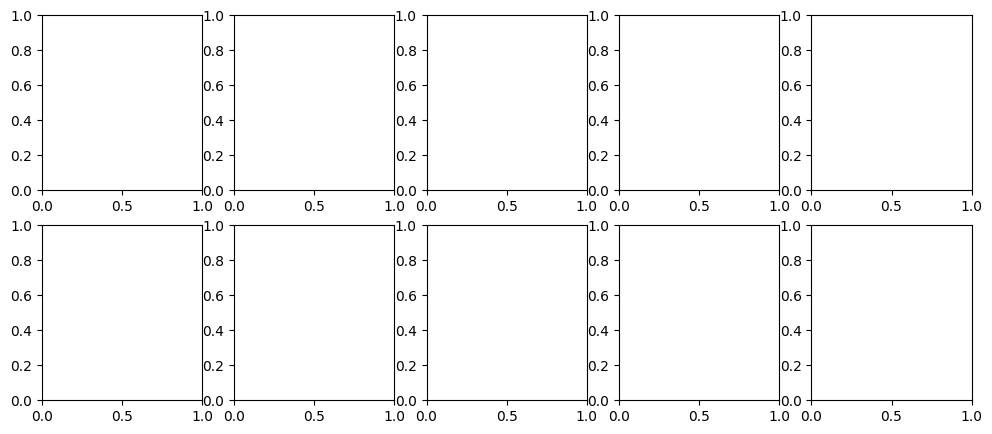

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(X_test))
    img = X_test[idx].reshape(64, 64)
    true_label = y_test[idx]
    with torch.no_grad():
        pred = model(torch.tensor(X_test[idx:idx+1], dtype=torch.float32).to(device)).argmax(dim=1).item()
    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_label} | Pred: {pred}", fontsize=9,
                 color='green' if pred == true_label else 'red')
    ax.axis('off')
plt.suptitle("Sample Predictions")
plt.tight_layout()
plt.show()